<a href="https://colab.research.google.com/github/01241008/simulasi-model-ising-2d/blob/main/ising_metropolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulasi Model Ising 2D Menggunakan Algoritma Metropolis

Nama Kelompok : Mekdi
1. Lidya Moulina 01241008
2. Lodia Vrita Sari 01241009
3. Umrotul Mafiroh 012410024

Komputasi Fisika

## Pendahuluan

Model Ising dua dimensi digunakan untuk mempelajari fenomena magnetisme dan transisi fase. Setiap titik pada kisi memiliki spin bernilai +1 atau -1 yang berinteraksi dengan tetangga terdekatnya.

Pada tugas ini digunakan algoritma Metropolis Monte Carlo untuk mensimulasikan perilaku sistem pada tiga kondisi temperatur:

1. T = 1.0 (Fase Feromagnetik)
2. T = 2.27 (Temperatur Kritis)
3. T = 4.0 (Fase Paramagnetik)


## Dasar Teori

Energi sistem Ising diberikan oleh

E = -J Σ(si sj)

dengan:
- J = konstanta interaksi
- si dan sj = spin tetangga

Dalam algoritma Metropolis, spin dipilih secara acak untuk dibalik.

Jika ΔE ≤ 0 maka perubahan diterima.

Jika ΔE > 0 maka perubahan diterima dengan probabilitas:

P = exp(-ΔE/T)

In [41]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
N = 20

def initialize_lattice(N):
    return np.random.choice([-1, 1], size=(N, N))

def delta_energy(lattice, i, j):

    spin = lattice[i, j]

    neighbors = (
        lattice[(i+1)%N, j] +
        lattice[(i-1)%N, j] +
        lattice[i, (j+1)%N] +
        lattice[i, (j-1)%N]
    )

    return 2 * spin * neighbors

def magnetization(lattice):
    return np.sum(lattice) / (N*N)

In [43]:
def metropolis_simulation(T,
                          N=20,
                          mc_steps=200000,
                          measure_every=100):

    lattice = initialize_lattice(N)

    magnetization_history = []

    for step in range(mc_steps):

        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        dE = delta_energy(lattice, i, j)

        if dE <= 0:
            lattice[i, j] *= -1

        elif np.random.rand() < np.exp(-dE/T):
            lattice[i, j] *= -1

        if step % measure_every == 0:
            magnetization_history.append(
                magnetization(lattice)
            )

    return lattice, magnetization_history

## Kasus 1 : Fase Feromagnetik (T = 1.0)


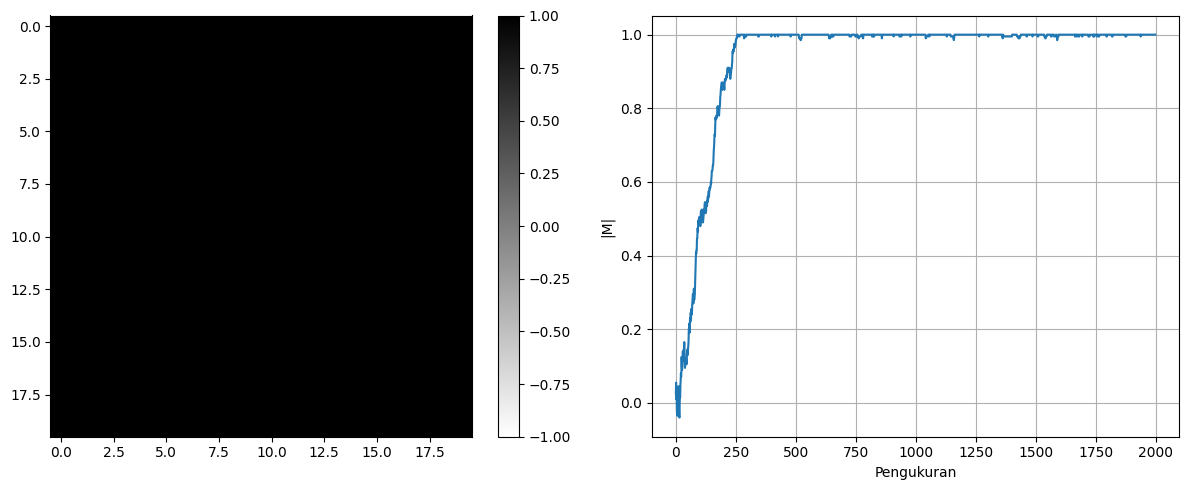

Magnetisasi akhir = 1.0
Spin unik = [1]


In [44]:
lattice1, mag1 = metropolis_simulation(T=1.0)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

im = ax[0].imshow(
    lattice1,
    cmap='binary',
    vmin=-1,
    vmax=1
)

plt.colorbar(im, ax=ax[0])

ax[1].plot(mag1)
ax[1].set_xlabel("Pengukuran")
ax[1].set_ylabel("|M|")
ax[1].grid(True)

plt.tight_layout()
plt.show()

print("Magnetisasi akhir =", mag1[-1])
print("Spin unik =", np.unique(lattice1))

### Analisis

Pada temperatur rendah (T = 1.0), energi sistem mendominasi pengaruh termal. Spin cenderung tersusun searah sehingga terbentuk domain besar yang seragam.

Nilai magnetisasi rata-rata mendekati satu yang menunjukkan fase feromagnetik.

# Kasus 2: Transisi Fasa dan Kritikalitas (T = 2.27)

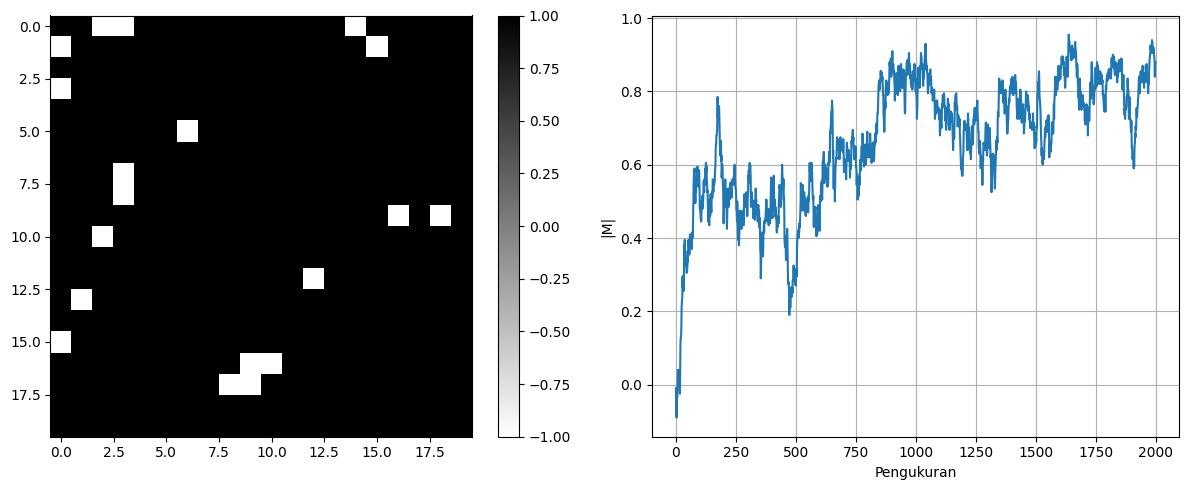

Magnetisasi akhir = 0.88
Spin unik = [-1  1]


In [45]:
lattice2, mag2 = metropolis_simulation(T=2.27)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

im = ax[0].imshow(
    lattice2,
    cmap='binary',
    vmin=-1,
    vmax=1
)

plt.colorbar(im, ax=ax[0])

ax[1].plot(mag2)
ax[1].set_xlabel("Pengukuran")
ax[1].set_ylabel("|M|")
ax[1].grid(True)

plt.tight_layout()
plt.show()

print("Magnetisasi akhir =", mag2[-1])
print("Spin unik =", np.unique(lattice2))

### Analisis

Pada T = 2.27 sistem berada di sekitar suhu kritis (Tc). Domain spin mulai terbentuk dan hancur secara terus-menerus akibat kompetisi antara interaksi spin dan fluktuasi termal. Magnetisasi berfluktuasi lebih kuat dibandingkan fase feromagnetik dan keteraturan jangka panjang mulai menghilang.

# Kasus 3: Fase Paramagnetik (T = 4.0)

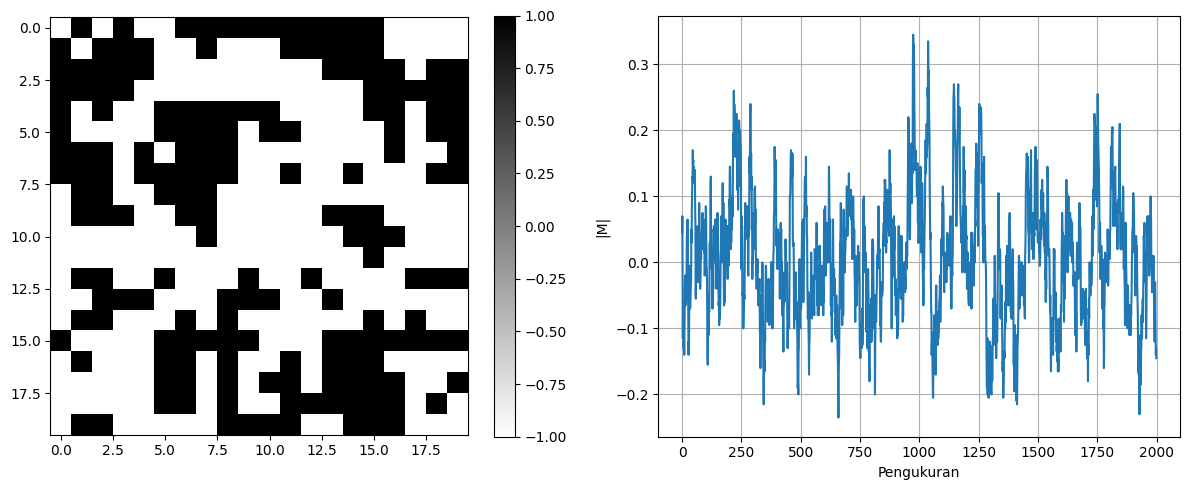

Magnetisasi akhir = -0.145
Spin unik = [-1  1]


In [46]:
lattice3, mag3 = metropolis_simulation(T=4.0)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

im = ax[0].imshow(
    lattice3,
    cmap='binary',
    vmin=-1,
    vmax=1
)

plt.colorbar(im, ax=ax[0])

ax[1].plot(mag3)
ax[1].set_xlabel("Pengukuran")
ax[1].set_ylabel("|M|")
ax[1].grid(True)

plt.tight_layout()
plt.show()

print("Magnetisasi akhir =", mag3[-1])
print("Spin unik =", np.unique(lattice3))

### Analisis

Pada T = 4.0 energi termal mendominasi sistem sehingga orientasi spin menjadi acak. Domain magnetik yang stabil tidak dapat terbentuk dan magnetisasi rata-rata mendekati nol. Kondisi ini menunjukkan sistem berada pada fase paramagnetik.